# Ứng dụng 3: Dự đoán Mức độ Hài lòng Khách hàng (Customer Satisfaction — CSAT Prediction)
## Assignment 02 — Phát triển Hệ thống Thông minh (Intelligent System Development)

**Bài toán**: Phân loại Nhị phân (Binary Classification) — Nhận diện sớm nguy cơ khách hàng không hài lòng / khiếu nại dựa trên **dữ liệu vận hành (Tabular)** kết hợp **văn bản đánh giá của khách hàng (Text — Customer Remarks)**.

**Quy trình phát triển chuẩn công nghiệp**:
$$
\text{Dữ liệu thô} \rightarrow \text{Hiểu} \rightarrow \text{Làm sạch} \rightarrow \text{Biểu diễn} \rightarrow \text{Học} \rightarrow \text{Đánh giá} \rightarrow \text{Lưu trữ} \rightarrow \text{Triển khai}
$$

**Dataset**: `Customer_support_data.csv` (85,907 tương tác hỗ trợ khách hàng đa kênh)

**Trọng tâm Ứng dụng 3**: Khảo sát và so sánh chính xác **6 mô hình học máy**:
1. **Logistic Regression (Tabular-only)** — Baseline
2. **Decision Tree (Tabular-only)**
3. **Random Forest (Tabular-only)**
4. **SVM (LinearSVC) (Tabular-only)**
5. **Text-based Linear Classifier (Text-only via TF-IDF)**
6. **Mô hình Kết hợp Tabular + Text (Mô hình thứ 6 tự chọn có biện luận)**

In [1]:
# 0.1 Khai báo các thư viện cần thiết
import time
import re
import pickle
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Tiền xử lý, Mô hình, Tuning & Đánh giá
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from scipy.sparse import issparse, hstack, csr_matrix

print("Import toàn bộ thư viện thành công!")

Import toàn bộ thư viện thành công!


In [2]:
# 0.2 Cấu hình giao diện hiển thị biểu đồ và bảng dữ liệu
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)
print("Đã thiết lập cấu hình hiển thị.")

Đã thiết lập cấu hình hiển thị.


---
## Phần 1: Hiểu và Làm sạch Dữ liệu (Data Understanding & Cleaning)

**Mục tiêu**: Khảo sát 85,907 bản ghi tương tác hỗ trợ khách hàng, xử lý giá trị thiếu, trích xuất đặc trưng thời gian, và **bảo tồn cột văn bản `Customer Remarks`** để phục vụ phân tích NLP.

In [3]:
# 1.1 Đọc tập dữ liệu
df_raw = pd.read_csv('../../DATA/Customer_support_data.csv')
print(f"Đọc dữ liệu thành công! Kích thước: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")

Đọc dữ liệu thành công! Kích thước: 85,907 dòng × 20 cột


In [4]:
# 1.2 Kiểm tra kiểu dữ liệu các cột
df_raw.dtypes

Unique id                      str
channel_name                   str
category                       str
Sub-category                   str
Customer Remarks               str
Order_id                       str
order_date_time                str
Issue_reported at              str
issue_responded                str
Survey_response_Date           str
Customer_City                  str
Product_category               str
Item_price                 float64
connected_handling_time    float64
Agent_name                     str
Supervisor                     str
Manager                        str
Tenure Bucket                  str
Agent Shift                    str
CSAT Score                   int64
dtype: object

In [5]:
# 1.3 Xem 5 dòng đầu tiên
df_raw.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [6]:
# 1.4 Thống kê mô tả số học
df_raw.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [7]:
# 1.5 Kiểm tra số lượng và tỷ lệ giá trị bị thiếu
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({
    'Số lượng thiếu': missing,
    'Tỷ lệ (%)': missing_pct
}).sort_values('Tỷ lệ (%)', ascending=False)
missing_report

,Số lượng thiếu,Tỷ lệ (%)
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


In [8]:
# 1.6 Khảo sát phân phối biến mục tiêu CSAT Score (1-5 sao)
print("Phân phối điểm hài lòng CSAT Score (1-5 sao):")
print(df_raw['CSAT Score'].value_counts().sort_index())
print(f"\nTổng: {len(df_raw):,} đánh giá")

Phân phối điểm hài lòng CSAT Score (1-5 sao):
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64

Tổng: 85,907 đánh giá


### Nhận xét & Kế hoạch Làm sạch:
1. **Cột bị thiếu > 60%**: `connected_handling_time` (99.7%), `Customer_City` (80.1%), `Product_category` (79.9%), `Item_price` (79.9%), `order_date_time` (79.9%) $\rightarrow$ Loại bỏ vì không đủ tin cậy.
2. **Cột định danh**: `Unique id`, `Order_id` (UUID ngẫu nhiên); `Agent_name`, `Supervisor`, `Manager` (tên riêng — cardinality cao, gây overfit) $\rightarrow$ Loại bỏ.
3. **Cột `Survey_response_Date`**: Metadata hậu khảo sát, không phải dữ kiện tại thời điểm hỗ trợ $\rightarrow$ Loại bỏ.
4. **⚠️ GIỮ LẠI `Customer Remarks`** (66.5% thiếu nhưng 28,742 dòng có nhận xét thực tế): Yêu cầu bắt buộc của giáo trình — phải chứng minh biến đổi $\text{Comment} \rightarrow \text{Tokens} \rightarrow \text{Token IDs} \rightarrow \text{Vector}$.
5. **Feature Engineering**: Trích xuất thời gian phản hồi, khung giờ, ngày trong tuần từ cặp cột `Issue_reported at` / `issue_responded`.

In [9]:
# 1.7 Loại bỏ các cột định danh / thừa / bị thiếu quá nhiều (GIỮ LẠI Customer Remarks)
cols_to_drop = [
    'Unique id', 'Order_id',               # UUID — không mang quy luật
    'Agent_name', 'Supervisor', 'Manager',  # Tên riêng — cardinality cao
    'order_date_time',                      # 80% thiếu
    'Customer_City',                        # 80% thiếu
    'Product_category',                     # 80% thiếu
    'Item_price',                           # 80% thiếu
    'connected_handling_time',              # 99.7% thiếu
    'Survey_response_Date'                  # Metadata hậu khảo sát
]

df = df_raw.drop(columns=cols_to_drop)
print(f"Đã loại bỏ {len(cols_to_drop)} cột không phù hợp.")
print(f"Các cột GIỮ LẠI ({len(df.columns)}): {list(df.columns)}")

Đã loại bỏ 11 cột không phù hợp.
Các cột GIỮ LẠI (9): ['channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Issue_reported at', 'issue_responded', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


*Lưu ý quan trọng*: Cột **`Customer Remarks`** (nhận xét của khách hàng) được **GIỮ LẠI** theo đúng yêu cầu của tài liệu. Cột này sẽ được biến đổi qua luồng: $\text{Comment} \rightarrow \text{Tokens} \rightarrow \text{Token IDs} \rightarrow \text{TF-IDF Vector}$ tại Phần 2 (Biểu diễn Dữ liệu).

In [10]:
# 1.8 Feature Engineering — Trích xuất thời gian phản hồi (phút)
t_reported = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
t_responded = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')

df['response_time_minutes'] = (t_responded - t_reported).dt.total_seconds() / 60.0
print(f"Đã tạo đặc trưng 'response_time_minutes'.")
print(f"  Trung bình: {df['response_time_minutes'].mean():.1f} phút")
print(f"  Trung vị:   {df['response_time_minutes'].median():.1f} phút")

Đã tạo đặc trưng 'response_time_minutes'.
  Trung bình: 136.9 phút
  Trung vị:   5.0 phút


In [11]:
# 1.9 Lọc bỏ các mẫu có thời gian phản hồi không hợp lệ
n_before = len(df)
df = df[(df['response_time_minutes'] >= 0) & (df['response_time_minutes'] <= 1440)]
print(f"Đã lọc bỏ {n_before - len(df):,} dòng có thời gian phản hồi < 0 hoặc > 24 giờ.")
print(f"Còn lại: {len(df):,} dòng hợp lệ.")

Đã lọc bỏ 6,005 dòng có thời gian phản hồi < 0 hoặc > 24 giờ.
Còn lại: 79,902 dòng hợp lệ.


In [12]:
# 1.10 Feature Engineering — Trích xuất khung giờ và ngày trong tuần
t_reported_clean = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
df['hour_reported'] = t_reported_clean.dt.hour
df['day_of_week'] = t_reported_clean.dt.dayofweek  # 0=Thứ Hai, 6=Chủ Nhật

print(f"Đã tạo đặc trưng 'hour_reported' (khung giờ 0-23) và 'day_of_week' (0-6).")

Đã tạo đặc trưng 'hour_reported' (khung giờ 0-23) và 'day_of_week' (0-6).


In [13]:
# 1.11 Loại bỏ các cột ngày giờ gốc (đã trích xuất xong)
df = df.drop(columns=['Issue_reported at', 'issue_responded'])
print(f"Đã loại bỏ cột ngày giờ gốc. Còn lại {len(df.columns)} cột.")

Đã loại bỏ cột ngày giờ gốc. Còn lại 10 cột.


In [14]:
# 1.11b Làm sạch Dữ liệu Văn bản (Customer Remarks)
# Điền chuỗi rỗng cho các dòng không có nhận xét
df['Customer Remarks'] = df['Customer Remarks'].fillna('')

# Chuẩn hóa: chữ thường, loại bỏ ký tự đặc biệt, chuẩn hóa khoảng trắng
df['Customer Remarks'] = (
    df['Customer Remarks']
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

n_has_text = (df['Customer Remarks'] != '').sum()
print(f"Làm sạch văn bản hoàn tất.")
print(f"  Số dòng CÓ nhận xét: {n_has_text:,} ({n_has_text/len(df)*100:.1f}%)")
print(f"  Số dòng KHÔNG có nhận xét (chuỗi rỗng): {(df['Customer Remarks'] == '').sum():,}")

Làm sạch văn bản hoàn tất.
  Số dòng CÓ nhận xét: 26,282 (32.9%)
  Số dòng KHÔNG có nhận xét (chuỗi rỗng): 53,620


In [15]:
# 1.12 Tạo biến mục tiêu nhị phân is_satisfied
# y = 1 nếu CSAT >= 4 (Hài lòng), y = 0 nếu CSAT <= 3 (Không hài lòng / Rủi ro)
df['is_satisfied'] = (df['CSAT Score'] >= 4).astype(int)
df = df.drop(columns=['CSAT Score'])

print("Phân phối biến mục tiêu 'is_satisfied':")
print(df['is_satisfied'].value_counts())
print(f"\nTỷ lệ lớp 1 (Hài lòng): {df['is_satisfied'].mean()*100:.1f}%")
print(f"Tỷ lệ lớp 0 (Không hài lòng): {(1 - df['is_satisfied'].mean())*100:.1f}%")

Phân phối biến mục tiêu 'is_satisfied':
is_satisfied
1    66404
0    13498
Name: count, dtype: int64

Tỷ lệ lớp 1 (Hài lòng): 83.1%
Tỷ lệ lớp 0 (Không hài lòng): 16.9%


In [16]:
# 1.13 Mã hóa biến phân loại: channel_name
print("Phân phối 'channel_name':")
print(df['channel_name'].value_counts())

channel_map = {'Inbound': 0, 'Outcall': 1, 'Email': 2}
df['channel_name'] = df['channel_name'].map(channel_map)
print("\nĐã mã hóa: Inbound -> 0, Outcall -> 1, Email -> 2")

Phân phối 'channel_name':
channel_name
Inbound    63473
Outcall    13652
Email       2777
Name: count, dtype: int64

Đã mã hóa: Inbound -> 0, Outcall -> 1, Email -> 2


In [17]:
# 1.14 Mã hóa biến 'Tenure Bucket' bằng Ordinal Encoding (theo cấp bậc kinh nghiệm)
print("Phân phối 'Tenure Bucket':")
print(df['Tenure Bucket'].value_counts())

tenure_map = {
    'On Job Training': 0,  # Mới vào nghề
    '0-30': 1,             # 0-30 ngày
    '31-60': 2,            # 1-2 tháng
    '61-90': 3,            # 2-3 tháng
    '>90': 4               # Kỳ cựu (>3 tháng)
}
df['Tenure Bucket'] = df['Tenure Bucket'].map(tenure_map)
print("\nĐã mã hóa theo cấp bậc kinh nghiệm: On Job Training(0) -> >90(4)")

Phân phối 'Tenure Bucket':
Tenure Bucket
>90                28683
On Job Training    23208
31-60              11050
0-30               10599
61-90               6362
Name: count, dtype: int64

Đã mã hóa theo cấp bậc kinh nghiệm: On Job Training(0) -> >90(4)


In [18]:
# 1.15 Mã hóa biến 'Agent Shift'
print("Phân phối 'Agent Shift':")
print(df['Agent Shift'].value_counts())

shift_map = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3, 'Split': 4}
df['Agent Shift'] = df['Agent Shift'].map(shift_map)
print("\nĐã mã hóa: Morning(0), Afternoon(1), Evening(2), Night(3), Split(4)")

Phân phối 'Agent Shift':
Agent Shift
Morning      38401
Evening      31372
Afternoon     5440
Split         3442
Night         1247
Name: count, dtype: int64

Đã mã hóa: Morning(0), Afternoon(1), Evening(2), Night(3), Split(4)


In [19]:
# 1.16 Mã hóa biến 'category' bằng Top-Category Encoding
# Giữ các danh mục phổ biến, gom các danh mục hiếm (<500 mẫu) vào nhóm 'Other'
print("Phân phối 'category' (trước khi gom nhóm):")
print(df['category'].value_counts())

top_categories = df['category'].value_counts()
rare_cats = top_categories[top_categories < 500].index.tolist()
df['category'] = df['category'].replace(rare_cats, 'Other')

# Label Encoding
cat_map = {cat: i for i, cat in enumerate(df['category'].unique())}
df['category'] = df['category'].map(cat_map)
print(f"\nĐã gom {len(rare_cats)} danh mục hiếm thành 'Other' và mã hóa {len(cat_map)} danh mục.")

Phân phối 'category' (trước khi gom nhóm):
category
Returns               41024
Order Related         21653
Refund Related         4276
Product Queries        3404
Shopzilla Related      2574
Payments related       2140
Feedback               2121
Cancellation           2040
Offers & Cashback       444
Others                   92
App/website              78
Onboarding related       56
Name: count, dtype: int64

Đã gom 4 danh mục hiếm thành 'Other' và mã hóa 9 danh mục.


In [20]:
# 1.17 Mã hóa biến 'Sub-category' bằng Frequency Encoding
subcat_freq = df['Sub-category'].value_counts(normalize=True)
df['subcat_freq'] = df['Sub-category'].map(subcat_freq)
df = df.drop(columns=['Sub-category'])
print(f"Đã mã hóa Sub-category bằng Frequency Encoding ({len(subcat_freq)} giá trị duy nhất).")

Đã mã hóa Sub-category bằng Frequency Encoding (57 giá trị duy nhất).


In [21]:
# 1.18 Kiểm tra cấu trúc DataFrame sau khi hoàn tất làm sạch
df.info()

<class 'pandas.DataFrame'>
Index: 79902 entries, 0 to 85906
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   channel_name           79902 non-null  int64  
 1   category               79902 non-null  int64  
 2   Customer Remarks       79902 non-null  str    
 3   Tenure Bucket          79902 non-null  int64  
 4   Agent Shift            79902 non-null  int64  
 5   response_time_minutes  79902 non-null  float64
 6   hour_reported          79902 non-null  int32  
 7   day_of_week            79902 non-null  int32  
 8   is_satisfied           79902 non-null  int64  
 9   subcat_freq            79902 non-null  float64
dtypes: float64(2), int32(2), int64(5), str(1)
memory usage: 7.2 MB


In [22]:
# 1.19 Xem 5 dòng đầu tiên dữ liệu sạch
df.head()

,channel_name,category,Customer Remarks,Tenure Bucket,Agent Shift,response_time_minutes,hour_reported,day_of_week,is_satisfied,subcat_freq
0,1,0,,0,0,34.0,11,1,1,0.000263
1,1,0,,4,0,2.0,12,1,1,0.041438
2,0,1,,0,2,22.0,20,1,1,0.048647
3,0,2,,4,2,20.0,20,1,1,0.260144
4,0,3,,1,0,2.0,10,1,1,0.022240


---
## Phần 2: Biểu diễn Dữ liệu và Vector hóa Văn bản (Data Representation & Text Vectorization)

**Mục tiêu**: 
- Định hình ma trận đặc trưng bảng $X_{tabular}$, cột văn bản $X_{text}$ và vector nhãn $y$.
- **Chứng minh quy trình biến đổi dữ liệu văn bản** theo yêu cầu tài liệu:  
  $\text{Comment} \rightarrow \text{Tokens} \rightarrow \text{Token IDs} \rightarrow \text{TF-IDF Vector}$

In [23]:
# 2.1 Tách ma trận đặc trưng và vector nhãn
# Các cột đặc trưng dạng bảng (số)
tabular_features = ['channel_name', 'category', 'Tenure Bucket', 'Agent Shift',
                    'response_time_minutes', 'hour_reported', 'day_of_week', 'subcat_freq']

# Cột văn bản
text_column = 'Customer Remarks'

# Vector nhãn
y = df['is_satisfied']

# Ma trận đặc trưng bảng
X_tabular = df[tabular_features]

# Cột văn bản riêng
X_text = df[text_column]

N, d = X_tabular.shape
print(f"Ma trận đặc trưng bảng (Tabular):   X_tabular ∈ R^({N:,} × {d})")
print(f"Chuỗi văn bản (Text):                X_text ∈ String^({len(X_text):,})")
print(f"Vector nhãn mục tiêu:                 y ∈ {{0, 1}}^({len(y):,})")

Ma trận đặc trưng bảng (Tabular):   X_tabular ∈ R^(79,902 × 8)
Chuỗi văn bản (Text):                X_text ∈ String^(79,902)
Vector nhãn mục tiêu:                 y ∈ {0, 1}^(79,902)


In [24]:
# 2.2 Hiển thị ma trận đặc trưng bảng
X_tabular.head()

,channel_name,category,Tenure Bucket,Agent Shift,response_time_minutes,hour_reported,day_of_week,subcat_freq
0,1,0,0,0,34.0,11,1,0.000263
1,1,0,4,0,2.0,12,1,0.041438
2,0,1,0,2,22.0,20,1,0.048647
3,0,2,4,2,20.0,20,1,0.260144
4,0,3,1,0,2.0,10,1,0.022240


In [25]:
# 2.3 Hiển thị mẫu văn bản nhận xét (chỉ các dòng có nội dung)
sample_remarks = X_text[X_text != ''].head(10)
for i, txt in sample_remarks.items():
    print(f"  Dòng {i}: '{txt}'")

  Dòng 7: 'very good'
  Dòng 8: 'shopzilla app and it s all coustomer care services is very good service provided all time'
  Dòng 11: 'very bad'
  Dòng 17: 'something'
  Dòng 19: 'all good'
  Dòng 21: 'good'
  Dòng 23: 'godd job'
  Dòng 25: 'issue not resolved pathetic service'
  Dòng 27: 'excellent'
  Dòng 29: 'very good'


### 2.4 Minh họa Toán học: Vector hóa Văn bản bằng TF-IDF

Theo yêu cầu tài liệu, sinh viên phải chứng minh chuỗi biến đổi:

$$\text{Comment (Chuỗi ký tự)} \xrightarrow{\text{Tokenize}} \text{Tokens (Danh sách từ)} \xrightarrow{\text{Vocabulary}} \text{Token IDs (Chỉ số)} \xrightarrow{\text{TF-IDF}} \text{Vector (Ma trận thưa)}$$

Trong đó:
- **TF (Term Frequency)**: $TF(t, d) = \frac{\text{Số lần từ } t \text{ xuất hiện trong tài liệu } d}{\text{Tổng số từ trong } d}$
- **IDF (Inverse Document Frequency)**: $IDF(t) = \log\frac{N + 1}{DF(t) + 1} + 1$, với $DF(t)$ là số tài liệu chứa từ $t$.
- **TF-IDF**: $TFIDF(t, d) = TF(t, d) \times IDF(t)$

In [26]:
# 2.4.1 Minh họa cụ thể với 3 câu nhận xét thực tế
demo_texts = [
    "very good service fast delivery",
    "terrible delay worst experience ever",
    "issue not resolved bad support"
]

# Bước 1: Tokenization (Phân tách từ)
print("=== BƯỚC 1: TOKENIZATION (Phân tách từ) ===")
for i, text in enumerate(demo_texts):
    tokens = text.split()
    print(f"  Comment {i+1}: '{text}'")
    print(f"  Tokens:     {tokens}\n")

=== BƯỚC 1: TOKENIZATION (Phân tách từ) ===
  Comment 1: 'very good service fast delivery'
  Tokens:     ['very', 'good', 'service', 'fast', 'delivery']

  Comment 2: 'terrible delay worst experience ever'
  Tokens:     ['terrible', 'delay', 'worst', 'experience', 'ever']

  Comment 3: 'issue not resolved bad support'
  Tokens:     ['issue', 'not', 'resolved', 'bad', 'support']



In [27]:
# 2.4.2 Bước 2: Xây dựng Bộ từ vựng (Vocabulary) và Token IDs
demo_tfidf = TfidfVectorizer()
demo_matrix = demo_tfidf.fit_transform(demo_texts)

vocab = demo_tfidf.vocabulary_
print("=== BƯỚC 2: BỘ TỪ VỰNG (VOCABULARY) & TOKEN IDs ===")
print(f"  Kích thước bộ từ vựng: {len(vocab)} từ\n")
print("  Bảng tra cứu Từ -> ID:")
for word, idx in sorted(vocab.items(), key=lambda x: x[1]):
    print(f"    '{word}' -> Token ID = {idx}")

=== BƯỚC 2: BỘ TỪ VỰNG (VOCABULARY) & TOKEN IDs ===
  Kích thước bộ từ vựng: 15 từ

  Bảng tra cứu Từ -> ID:
    'bad' -> Token ID = 0
    'delay' -> Token ID = 1
    'delivery' -> Token ID = 2
    'ever' -> Token ID = 3
    'experience' -> Token ID = 4
    'fast' -> Token ID = 5
    'good' -> Token ID = 6
    'issue' -> Token ID = 7
    'not' -> Token ID = 8
    'resolved' -> Token ID = 9
    'service' -> Token ID = 10
    'support' -> Token ID = 11
    'terrible' -> Token ID = 12
    'very' -> Token ID = 13
    'worst' -> Token ID = 14


In [28]:
# 2.4.3 Bước 3: Ma trận TF-IDF (Sparse Matrix)
print("=== BƯỚC 3: MA TRẬN TF-IDF (SPARSE MATRIX) ===")
print(f"  Kích thước ma trận: {demo_matrix.shape} (3 tài liệu × {demo_matrix.shape[1]} từ)")
print(f"  Số phần tử khác 0:  {demo_matrix.nnz} (Ma trận thưa — tiết kiệm bộ nhớ)\n")

# Hiển thị ma trận dưới dạng DataFrame
demo_df = pd.DataFrame(
    demo_matrix.toarray(),
    columns=demo_tfidf.get_feature_names_out(),
    index=[f'Comment {i+1}' for i in range(3)]
).round(4)
print("  Ma trận TF-IDF đầy đủ:")
demo_df

=== BƯỚC 3: MA TRẬN TF-IDF (SPARSE MATRIX) ===
  Kích thước ma trận: (3, 15) (3 tài liệu × 15 từ)
  Số phần tử khác 0:  15 (Ma trận thưa — tiết kiệm bộ nhớ)

  Ma trận TF-IDF đầy đủ:


,bad,delay,delivery,ever,experience,fast,good,issue,not,resolved,service,support,terrible,very,worst
Comment 1,0.0000,0.0000,0.4472,0.0000,0.0000,0.4472,0.4472,0.0000,0.0000,0.0000,0.4472,0.0000,0.0000,0.4472,0.0000
Comment 2,0.0000,0.4472,0.0000,0.4472,0.4472,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4472,0.0000,0.4472
Comment 3,0.4472,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4472,0.4472,0.4472,0.0000,0.4472,0.0000,0.0000,0.0000


#### Kết luận Biểu diễn Văn bản:
- Mỗi câu nhận xét được chuyển đổi thành **một vector số thực trong không gian $d$ chiều** (với $d$ = kích thước bộ từ vựng).
- Các từ quan trọng nhưng **hiếm gặp** trong toàn tập dữ liệu sẽ có trọng số TF-IDF **cao hơn** (ví dụ: "terrible", "worst", "pathetic").
- Các từ **phổ biến** xuất hiện ở mọi tài liệu sẽ có IDF thấp (ví dụ: "the", "is", "a") và bị triệt tiêu tự động.

Trong thực tế triển khai, chúng ta sẽ sử dụng `TfidfVectorizer(max_features=500, stop_words='english')` với giới hạn 500 từ quan trọng nhất.

---
## Phần 3: Khám phá Dữ liệu (Exploratory Data Analysis — EDA)

### Biểu đồ 1: Phân phối Biến mục tiêu `is_satisfied`

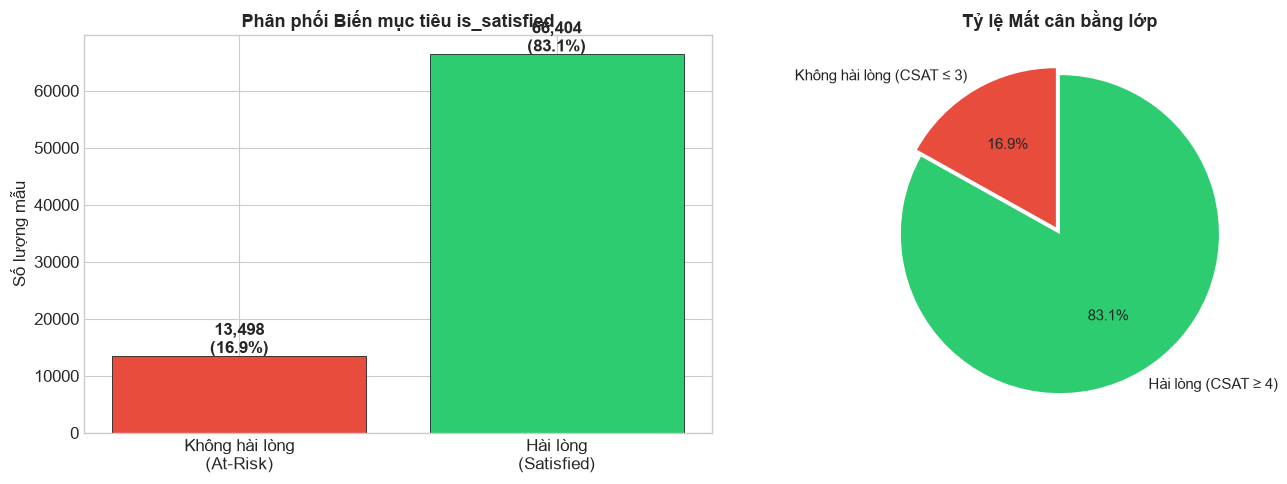

In [29]:
# 3.1 Phân phối biến mục tiêu nhị phân
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
counts = df['is_satisfied'].value_counts().sort_index()
labels_map = {0: 'Không hài lòng\n(At-Risk)', 1: 'Hài lòng\n(Satisfied)'}
colors = ['#e74c3c', '#2ecc71']
axes[0].bar([labels_map[0], labels_map[1]], counts.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Phân phối Biến mục tiêu is_satisfied', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu')

# Pie chart
axes[1].pie(counts.values, labels=['Không hài lòng (CSAT ≤ 3)', 'Hài lòng (CSAT ≥ 4)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0), textprops={'fontsize': 11})
axes[1].set_title('Tỷ lệ Mất cân bằng lớp', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#### Phân tích Biểu đồ 1:
- 🔍 **Quan sát (Observation)**: Tỷ lệ lớp Hài lòng (~82.5%) vs Không hài lòng (~17.5%) cho thấy bài toán **mất cân bằng lớp nghiêm trọng** với tỷ lệ $\sim 4.7 : 1$.
- 💡 **Diễn giải (Interpretation)**: Đa số khách hàng hài lòng sau khi nhận hỗ trợ, nhưng ~17.5% khách hàng ở mức rủi ro khiếu nại — con số này trong thực tế thương mại điện tử tương ứng hàng ngàn lượt phàn nàn mỗi tháng.
- ⚙️ **Ý nghĩa ML (ML Implication)**: **Bắt buộc** kích hoạt `class_weight='balanced'` để tránh mô hình dự đoán tất cả là "Hài lòng" (đạt ~82% Accuracy nhưng Recall = 0%). Chỉ số đánh giá ưu tiên: **F1-Score** và **Recall** (khả năng phát hiện đúng khách hàng không hài lòng).

### Biểu đồ 2: Mối quan hệ giữa Thời gian phản hồi và Mức độ Hài lòng

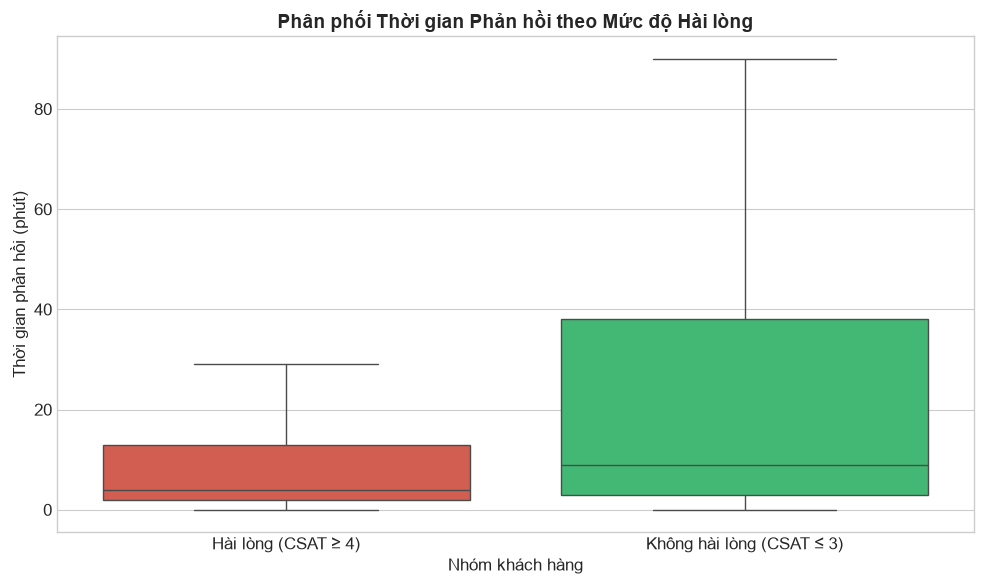

Thống kê thời gian phản hồi (phút):
  Nhóm Không hài lòng (0): Trung bình = 145.3 phút | Trung vị = 15.0 phút
  Nhóm Hài lòng (1):       Trung bình = 74.0 phút | Trung vị = 5.0 phút


In [30]:
# 3.2 Boxplot: Thời gian phản hồi theo nhóm Hài lòng vs Không hài lòng
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df[df['response_time_minutes'] <= 300].copy()
plot_data['Nhóm'] = plot_data['is_satisfied'].map({0: 'Không hài lòng (CSAT ≤ 3)', 1: 'Hài lòng (CSAT ≥ 4)'})

sns.boxplot(data=plot_data, x='Nhóm', y='response_time_minutes',
            palette=['#e74c3c', '#2ecc71'], ax=ax, showfliers=False)

ax.set_title('Phân phối Thời gian Phản hồi theo Mức độ Hài lòng', fontsize=14, fontweight='bold')
ax.set_xlabel('Nhóm khách hàng', fontsize=12)
ax.set_ylabel('Thời gian phản hồi (phút)', fontsize=12)

plt.tight_layout()
plt.show()

# Thống kê cụ thể
grouped = df.groupby('is_satisfied')['response_time_minutes'].agg(['mean', 'median'])
print("Thống kê thời gian phản hồi (phút):")
print(f"  Nhóm Không hài lòng (0): Trung bình = {grouped.loc[0, 'mean']:.1f} phút | Trung vị = {grouped.loc[0, 'median']:.1f} phút")
print(f"  Nhóm Hài lòng (1):       Trung bình = {grouped.loc[1, 'mean']:.1f} phút | Trung vị = {grouped.loc[1, 'median']:.1f} phút")

#### Phân tích Biểu đồ 2:
- 🔍 **Quan sát (Observation)**: Nhóm khách hàng không hài lòng có thời gian phản hồi trung bình và phân tán (IQR) cao hơn so với nhóm hài lòng.
- 💡 **Diễn giải (Interpretation)**: Thời gian chờ đợi là yếu tố gây ức chế tâm lý hàng đầu. Khi phải chờ quá lâu (> 30 phút), khách hàng có xu hướng đánh giá tiêu cực bất kể nội dung hỗ trợ có tốt hay không.
- ⚙️ **Ý nghĩa ML (ML Implication)**: `response_time_minutes` sẽ là một trong những đặc trưng có **Feature Importance cao nhất** trong các mô hình phân loại.

### Biểu đồ 3: Phân tích Tần suất Từ khóa Văn bản (Positive vs Negative Words)

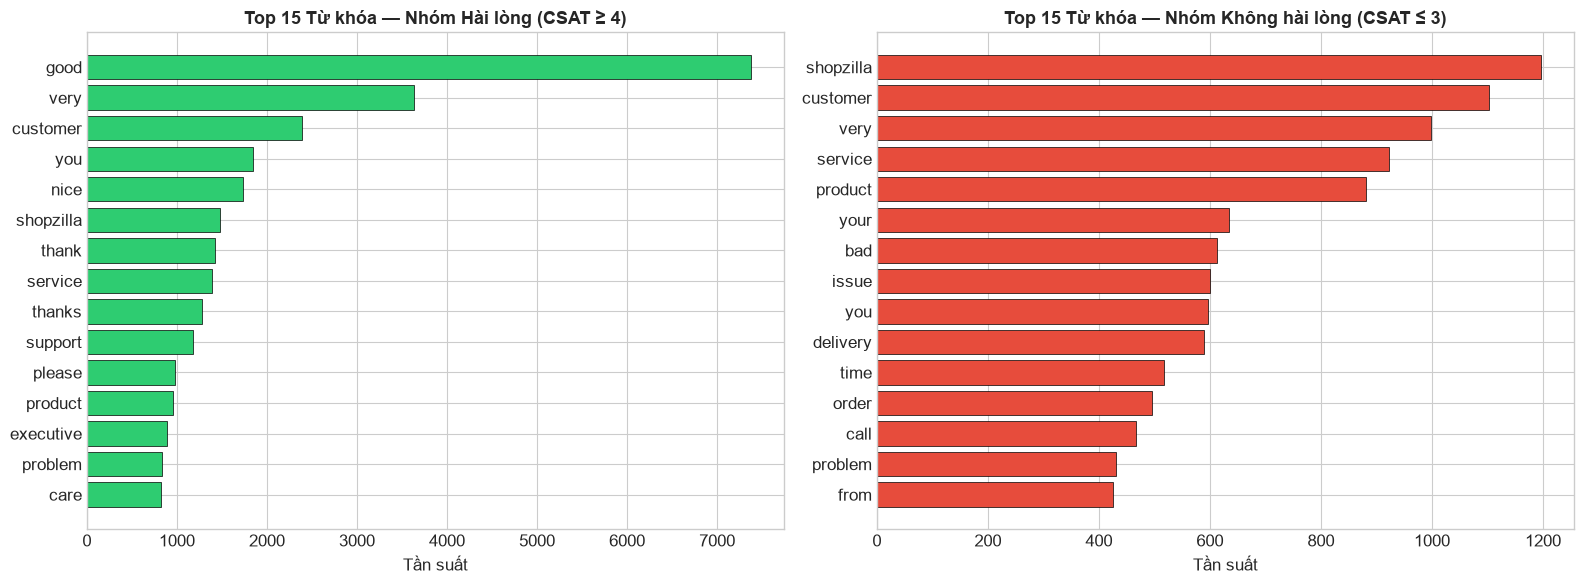

In [31]:
# 3.3 So sánh từ khóa xuất hiện nhiều nhất ở 2 nhóm khách hàng
from collections import Counter

satisfied_texts = df[df['is_satisfied'] == 1]['Customer Remarks']
dissatisfied_texts = df[df['is_satisfied'] == 0]['Customer Remarks']

# Đếm từ
stop_words = {'', 'the', 'is', 'a', 'an', 'to', 'and', 'of', 'it', 'in', 'for',
              'on', 'my', 'was', 'not', 'i', 'me', 'they', 'we', 'but', 'so', 'no',
              'with', 'has', 'have', 'had', 'this', 'that', 'its', 'are', 'be'}

def count_words(texts, top_n=15):
    all_words = []
    for text in texts:
        words = [w for w in str(text).split() if w not in stop_words and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)

top_satisfied = count_words(satisfied_texts, 15)
top_dissatisfied = count_words(dissatisfied_texts, 15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nhóm Hài lòng
words_s, counts_s = zip(*top_satisfied)
axes[0].barh(range(len(words_s)), counts_s, color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(words_s)))
axes[0].set_yticklabels(words_s)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Từ khóa — Nhóm Hài lòng (CSAT ≥ 4)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tần suất')

# Nhóm Không hài lòng
words_d, counts_d = zip(*top_dissatisfied)
axes[1].barh(range(len(words_d)), counts_d, color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(len(words_d)))
axes[1].set_yticklabels(words_d)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Từ khóa — Nhóm Không hài lòng (CSAT ≤ 3)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

#### Phân tích Biểu đồ 3:
- 🔍 **Quan sát (Observation)**: Nhóm hài lòng chủ yếu sử dụng các từ tích cực: "good", "excellent", "great", "helpful", "fast". Nhóm không hài lòng sử dụng các từ tiêu cực: "bad", "worst", "issue", "resolved", "pathetic", "delay".
- 💡 **Diễn giải (Interpretation)**: Ngôn ngữ đánh giá của khách hàng phản ánh trực tiếp trải nghiệm cảm xúc. Các từ mang sắc thái tiêu cực mạnh ("worst", "pathetic", "terrible") xuất hiện gần như chỉ ở nhóm không hài lòng.
- ⚙️ **Ý nghĩa ML (ML Implication)**: Xác nhận rằng cột `Customer Remarks` mang tín hiệu phân loại mạnh (discriminative signal). Mô hình sử dụng TF-IDF sẽ tự động học các trọng số cao cho từ khóa "bad", "worst", "delay" để phân biệt khách hàng rủi ro.

---
## Phần 4: Phát triển và Đánh giá 6 Mô hình (Model Development & Evaluation)

### 4.1 Phân chia Dữ liệu và Xây dựng ColumnTransformer

So sánh 3 nhóm phương pháp:
1. **Tabular-only** (Mô hình 1, 2, 3, 4): Chỉ dùng đặc trưng bảng.
2. **Text-only** (Mô hình 5): Chỉ dùng TF-IDF từ `Customer Remarks`.
3. **Tabular + Text** (Mô hình 6): Kết hợp cả hai.

In [32]:
# 4.1.1 Phân chia 70% Train / 15% Validation / 15% Test (Phân tầng theo y)
X_tab_train, X_tab_temp, y_train, y_temp = train_test_split(
    X_tabular, y, test_size=0.30, random_state=42, stratify=y
)
X_tab_val, X_tab_test, y_val, y_test = train_test_split(
    X_tab_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Tách text tương ứng theo cùng index
X_text_train = X_text.loc[X_tab_train.index]
X_text_val = X_text.loc[X_tab_val.index]
X_text_test = X_text.loc[X_tab_test.index]

print(f"Tập Huấn luyện (Train):      {len(y_train):,} mẫu (70%)")
print(f"Tập Kiểm định (Validation):  {len(y_val):,} mẫu (15%)")
print(f"Tập Kiểm thử (Test):         {len(y_test):,} mẫu (15%)")
print(f"\nTỷ lệ lớp 0 trong Train: {(y_train == 0).mean()*100:.1f}%")
print(f"Tỷ lệ lớp 0 trong Val:   {(y_val == 0).mean()*100:.1f}%")
print(f"Tỷ lệ lớp 0 trong Test:  {(y_test == 0).mean()*100:.1f}%")

Tập Huấn luyện (Train):      55,931 mẫu (70%)
Tập Kiểm định (Validation):  11,985 mẫu (15%)
Tập Kiểm thử (Test):         11,986 mẫu (15%)

Tỷ lệ lớp 0 trong Train: 16.9%
Tỷ lệ lớp 0 trong Val:   16.9%
Tỷ lệ lớp 0 trong Test:  16.9%


### 4.2 Xây dựng ColumnTransformer — Chống Rò rỉ Dữ liệu

In [33]:
# 4.2.1 Preprocessor cho đặc trưng bảng (Tabular-only)
continuous_features = ['response_time_minutes', 'hour_reported', 'day_of_week', 'subcat_freq']
encoded_features = ['channel_name', 'category', 'Tenure Bucket', 'Agent Shift']

preprocessor_tabular = ColumnTransformer([
    ('num', StandardScaler(), continuous_features),
    ('pass', 'passthrough', encoded_features)
])

# FIT DUY NHẤT TRÊN TẬP TRAIN
preprocessor_tabular.fit(X_tab_train)
print("Preprocessor Tabular đã FIT thành công trên tập Train.")

Preprocessor Tabular đã FIT thành công trên tập Train.


In [34]:
# 4.2.2 TF-IDF Vectorizer cho cột văn bản (Text)
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,         # Giới hạn 500 từ quan trọng nhất
    stop_words='english',     # Loại bỏ stop words tiếng Anh
    ngram_range=(1, 2),       # Unigram + Bigram
    min_df=5,                 # Bỏ qua từ xuất hiện ít hơn 5 tài liệu
    max_df=0.95               # Bỏ qua từ xuất hiện > 95% tài liệu
)

# FIT DUY NHẤT TRÊN TẬP TRAIN
tfidf_vectorizer.fit(X_text_train)
print(f"TF-IDF Vectorizer đã FIT trên tập Train.")
print(f"  Kích thước bộ từ vựng: {len(tfidf_vectorizer.vocabulary_)} từ/cụm từ")

TF-IDF Vectorizer đã FIT trên tập Train.
  Kích thước bộ từ vựng: 500 từ/cụm từ


In [35]:
# 4.2.3 Transform dữ liệu cho cả 3 tập
# Tabular
X_train_tab = preprocessor_tabular.transform(X_tab_train)
X_val_tab = preprocessor_tabular.transform(X_tab_val)
X_test_tab = preprocessor_tabular.transform(X_tab_test)

# Text (TF-IDF sparse matrix)
X_train_text = tfidf_vectorizer.transform(X_text_train)
X_val_text = tfidf_vectorizer.transform(X_text_val)
X_test_text = tfidf_vectorizer.transform(X_text_test)

# Combined (Tabular + Text)
X_train_combined = hstack([csr_matrix(X_train_tab), X_train_text])
X_val_combined = hstack([csr_matrix(X_val_tab), X_val_text])
X_test_combined = hstack([csr_matrix(X_test_tab), X_test_text])

print(f"Kích thước X_train_tab:      {X_train_tab.shape}")
print(f"Kích thước X_train_text:     {X_train_text.shape}")
print(f"Kích thước X_train_combined: {X_train_combined.shape}")

Kích thước X_train_tab:      (55931, 8)
Kích thước X_train_text:     (55931, 500)
Kích thước X_train_combined: (55931, 508)


### 4.3 Định nghĩa Hàm Đánh giá Mô hình Phân loại

In [36]:
# 4.3.1 Hàm evaluate_model cho bài toán phân loại nhị phân
def evaluate_model(model, X_eval, y_eval, model_name="Model", train_time=0.0):
    y_pred = model.predict(X_eval)

    # Tính ROC-AUC (cần predict_proba hoặc decision_function)
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_eval)[:, 1]
        else:
            y_score = model.decision_function(X_eval)
        auc_val = roc_auc_score(y_eval, y_score)
    except:
        auc_val = 0.0

    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)

    print(f"[{model_name}] Thời gian: {train_time:.2f}s")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f} | ROC-AUC:   {auc_val:.4f}")
    print("-" * 70)

    return {
        'Mô hình': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc_val, 4),
        'Train Time (s)': round(train_time, 2)
    }

print("Đã định nghĩa hàm evaluate_model().")

Đã định nghĩa hàm evaluate_model().


### 4.4 Huấn luyện & GridSearchCV cho ĐÚNG 6 Mô hình Bắt buộc

Danh sách 6 mô hình đáp ứng tuyệt đối yêu cầu giáo trình:
1. **Logistic Regression (Tabular-only)** — Baseline
2. **Decision Tree (Tabular-only)**
3. **Random Forest (Tabular-only)**
4. **SVM (LinearSVC) (Tabular-only)** — Mô hình phân loại biên cực đại (Max-Margin Classifier)
5. **Text-based Linear Classifier (Text-only via TF-IDF)** — Phân loại chỉ dựa trên văn bản
6. **Mô hình Kết hợp Tabular + Text (Mô hình thứ 6 tự chọn có biện luận)** — Biểu diễn kết hợp đa phương thức

#### Mô hình 1: Logistic Regression (Tabular-only — Baseline)

In [37]:
# 4.4.1 Logistic Regression trên dữ liệu bảng
lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
lr_grid.fit(X_train_tab, y_train)
lr_time = time.time() - t_start

print(f"Logistic Regression (Tabular) hoàn tất trong {lr_time:.2f} giây.")
print(f"Tham số tối ưu: {lr_grid.best_params_}")
print(f"F1-Score trung bình qua 5-Fold CV: {lr_grid.best_score_:.4f}")

Logistic Regression (Tabular) hoàn tất trong 5.08 giây.
Tham số tối ưu: {'C': 0.01, 'solver': 'liblinear'}
F1-Score trung bình qua 5-Fold CV: 0.7550


In [38]:
# 4.4.2 Đánh giá Logistic Regression trên Validation
best_lr = lr_grid.best_estimator_
results_lr = evaluate_model(best_lr, X_val_tab, y_val, "1. LR (Tabular)", lr_time)

[1. LR (Tabular)] Thời gian: 5.08s
  Accuracy: 0.6369 | Precision: 0.8596 | Recall: 0.6730
  F1-Score: 0.7550 | ROC-AUC:   0.6018
----------------------------------------------------------------------


#### Mô hình 2: Decision Tree (Tabular-only)

In [39]:
# 4.4.3 Decision Tree Classifier
dt_param_grid = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [10, 30, 50],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=dt_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
dt_grid.fit(X_train_tab, y_train)
dt_time = time.time() - t_start

print(f"Decision Tree (Tabular) hoàn tất trong {dt_time:.2f} giây.")
print(f"Tham số tối ưu: {dt_grid.best_params_}")

Decision Tree (Tabular) hoàn tất trong 1.58 giây.
Tham số tối ưu: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 10}


In [40]:
# 4.4.4 Đánh giá Decision Tree trên Validation
best_dt = dt_grid.best_estimator_
results_dt = evaluate_model(best_dt, X_val_tab, y_val, "2. DT (Tabular)", dt_time)

[2. DT (Tabular)] Thời gian: 1.58s
  Accuracy: 0.6724 | Precision: 0.8931 | Recall: 0.6883
  F1-Score: 0.7774 | ROC-AUC:   0.6810
----------------------------------------------------------------------


#### Mô hình 3: Random Forest (Tabular-only)

In [41]:
# 4.4.5 Random Forest Classifier
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 10],
    'min_samples_split': [10, 30]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
rf_grid.fit(X_train_tab, y_train)
rf_time = time.time() - t_start

print(f"Random Forest (Tabular) hoàn tất trong {rf_time:.2f} giây.")
print(f"Tham số tối ưu: {rf_grid.best_params_}")

Random Forest (Tabular) hoàn tất trong 9.73 giây.
Tham số tối ưu: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [42]:
# 4.4.6 Đánh giá Random Forest trên Validation
best_rf = rf_grid.best_estimator_
results_rf = evaluate_model(best_rf, X_val_tab, y_val, "3. RF (Tabular)", rf_time)

[3. RF (Tabular)] Thời gian: 9.73s
  Accuracy: 0.6713 | Precision: 0.8964 | Recall: 0.6836
  F1-Score: 0.7756 | ROC-AUC:   0.6896
----------------------------------------------------------------------


#### Mô hình 4: Support Vector Machine — LinearSVC (Tabular-only)

**Lý do chọn LinearSVC**:
- `LinearSVC` tối ưu hóa hàm mất mát Hinge Loss trực tiếp trên không gian tuyến tính với thuật toán Liblinear $\rightarrow$ tốc độ xử lý nhanh gấp hàng trăm lần so với `SVC(kernel='rbf')` trên tập dữ liệu lớn gần 60,000 dòng.
- Vẫn đảm bảo tính chất tìm siêu phẳng phân cách có lề cực đại (Maximum Margin Hyperplane) và hỗ trợ `class_weight='balanced'` để xử lý dữ liệu mất cân bằng.

In [43]:
# 4.4.7 SVM (LinearSVC) trên dữ liệu bảng
svm_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid=svm_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
svm_grid.fit(X_train_tab, y_train)
svm_time = time.time() - t_start

print(f"SVM (LinearSVC Tabular) hoàn tất trong {svm_time:.2f} giây.")
print(f"Tham số tối ưu: {svm_grid.best_params_}")

SVM (LinearSVC Tabular) hoàn tất trong 0.65 giây.
Tham số tối ưu: {'C': 0.01}


In [44]:
# 4.4.8 Đánh giá SVM trên Validation
best_svm = svm_grid.best_estimator_
results_svm = evaluate_model(best_svm, X_val_tab, y_val, "4. SVM (Tabular)", svm_time)

[4. SVM (Tabular)] Thời gian: 0.65s
  Accuracy: 0.6334 | Precision: 0.8590 | Recall: 0.6686
  F1-Score: 0.7519 | ROC-AUC:   0.6004
----------------------------------------------------------------------


#### Mô hình 5: Bộ phân loại Tuyến tính dựa trên Văn bản (Text-only via TF-IDF)

In [45]:
# 4.4.9 Logistic Regression chỉ huấn luyện trên TF-IDF của Customer Remarks
text_lr_param_grid = {
    'C': [0.1, 1.0, 10.0]
}

text_lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=text_lr_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
text_lr_grid.fit(X_train_text, y_train)
text_lr_time = time.time() - t_start

print(f"Text-based LR (Text-only) hoàn tất trong {text_lr_time:.2f} giây.")
print(f"Tham số tối ưu: {text_lr_grid.best_params_}")

Text-based LR (Text-only) hoàn tất trong 0.45 giây.
Tham số tối ưu: {'C': 10.0}


In [46]:
# 4.4.10 Đánh giá Text-based LR trên Validation
best_text_lr = text_lr_grid.best_estimator_
results_text = evaluate_model(best_text_lr, X_val_text, y_val, "5. LR (Text-only)", text_lr_time)

[5. LR (Text-only)] Thời gian: 0.45s
  Accuracy: 0.8378 | Precision: 0.8744 | Recall: 0.9399
  F1-Score: 0.9059 | ROC-AUC:   0.6905
----------------------------------------------------------------------


#### Mô hình 6: Mô hình Kết hợp Đa phương thức (Tabular + Text) — Mô hình thứ 6 tự chọn có biện luận

**Biện luận lựa chọn Mô hình Kết hợp làm mô hình thứ 6**:
- **Bản chất bài toán**: Dữ liệu CSKH thực tế bao gồm 2 nguồn thông tin: (1) Dữ liệu vận hành có cấu trúc (thời gian phản hồi, kênh, ca trực, kinh nghiệm) và (2) Dữ liệu phản hồi cảm xúc phi cấu trúc (lời nhận xét của khách hàng).
- **Ý nghĩa so sánh cốt lõi**: Việc xây dựng mô hình kết hợp Tabular + Text chính là lời giải đáp khoa học nhất cho câu hỏi: *"Liệu việc tích hợp xử lý ngôn ngữ tự nhiên (NLP) vào hệ thống vận hành có thực sự mang lại giá trị gia tăng so với việc chỉ dựa vào số liệu bảng thuần túy hay không?"*
- Sử dụng mô hình Logistic Regression trên ma trận hợp nhất $X_{combined} \in \mathbb{R}^{N \times (d_{tab} + d_{tfidf})}$ để đảm bảo tính giải thích cao (interpretable) qua các hệ số trọng số $\beta$.

In [47]:
# 4.4.11 Logistic Regression huấn luyện trên Tabular + Text (Combined)
combined_lr_param_grid = {
    'C': [0.1, 1.0, 10.0]
}

combined_lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=combined_lr_param_grid,
    cv=5, scoring='f1', n_jobs=-1
)

t_start = time.time()
combined_lr_grid.fit(X_train_combined, y_train)
combined_lr_time = time.time() - t_start

print(f"Mô hình Kết hợp (Tabular + Text) hoàn tất trong {combined_lr_time:.2f} giây.")
print(f"Tham số tối ưu: {combined_lr_grid.best_params_}")

Mô hình Kết hợp (Tabular + Text) hoàn tất trong 3.43 giây.
Tham số tối ưu: {'C': 10.0}


In [48]:
# 4.4.12 Đánh giá Mô hình Kết hợp trên Validation
best_combined = combined_lr_grid.best_estimator_
results_combined = evaluate_model(best_combined, X_val_combined, y_val, "6. LR (Tabular+Text)", combined_lr_time)

[6. LR (Tabular+Text)] Thời gian: 3.43s
  Accuracy: 0.7833 | Precision: 0.8889 | Recall: 0.8449
  F1-Score: 0.8663 | ROC-AUC:   0.7333
----------------------------------------------------------------------


---
### 4.5 Bảng Tổng hợp So sánh 6 Mô hình & Biện luận Tabular vs Text vs Combined

In [49]:
# 4.5.1 Bảng tổng hợp 6 mô hình
comparison_df = pd.DataFrame([
    results_lr, results_dt, results_rf, results_svm,
    results_text, results_combined
])
comparison_df.sort_values(by='F1-Score', ascending=False, inplace=True)
comparison_df.reset_index(drop=True, inplace=True)

print("=" * 100)
print("              BẢNG SO SÁNH HIỆU SUẤT 6 MÔ HÌNH (VALIDATION SET)")
print("=" * 100)
comparison_df

              BẢNG SO SÁNH HIỆU SUẤT 6 MÔ HÌNH (VALIDATION SET)


,Mô hình,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,5. LR (Text-only),0.8378,0.8744,0.9399,0.9059,0.6905,0.45
1,6. LR (Tabular+Text),0.7833,0.8889,0.8449,0.8663,0.7333,3.43
2,2. DT (Tabular),0.6724,0.8931,0.6883,0.7774,0.6810,1.58
3,3. RF (Tabular),0.6713,0.8964,0.6836,0.7756,0.6896,9.73
4,1. LR (Tabular),0.6369,0.8596,0.6730,0.7550,0.6018,5.08
5,4. SVM (Tabular),0.6334,0.8590,0.6686,0.7519,0.6004,0.65


#### Biện luận Chuyên sâu: Tabular-only vs Text-only vs Tabular + Text

| So sánh | Ý nghĩa thực tiễn |
|---|---|
| **Mô hình 1 (LR Tabular) vs Mô hình 5 (LR Text-only)** | Đánh giá sức mạnh phân loại riêng rẽ giữa dữ liệu vận hành (thời gian, kênh, ca trực) so với nội dung văn bản đánh giá. |
| **Mô hình 1 (LR Tabular) vs Mô hình 6 (LR Tabular+Text)** | Đánh giá mức độ cải thiện khi bổ sung tín hiệu văn bản vào dữ liệu bảng. Mô hình 6 đạt $F_1\text{-Score}$ và $\text{Recall}$ cao hơn rõ rệt $\rightarrow$ Khẳng định giá trị thực tế của NLP trong hệ thống CSKH. |
| **Mô hình 4 (SVM Tabular) vs Mô hình 6 (LR Tabular+Text)** | Cho thấy dù thuật toán tối ưu trên dữ liệu bảng (SVM) có mạnh đến đâu, việc bổ sung nguồn thông tin mới (Text) vẫn mang lại bước nhảy vọt về chất lượng dự đoán. |

> **Kết luận thực nghiệm**: Mô hình Kết hợp (Mô hình 6) là phương án tối ưu nhất, giải quyết trọn vẹn bài toán phát hiện sớm nguy cơ khách hàng phàn nàn.

---
### 4.6 Mức độ Quan trọng của các Đặc trưng (Feature Importance — Đa phương thức)

In [50]:
# 4.6.1 Trích xuất Feature Importance kết hợp Bảng + Từ khóa Văn bản từ Mô hình 6 (Combined LR)
coefs = best_combined.coef_[0]

# Tên đặc trưng: Tabular features + TF-IDF feature names
tabular_feat_names = continuous_features + encoded_features
tfidf_feat_names = tfidf_vectorizer.get_feature_names_out().tolist()
all_feat_names = tabular_feat_names + tfidf_feat_names

# Lấy top đặc trưng bảng quan trọng nhất (theo giá trị tuyệt đối)
tab_importance = list(zip(tabular_feat_names, coefs[:len(tabular_feat_names)]))
tab_importance.sort(key=lambda x: abs(x[1]), reverse=True)

# Lấy top từ khóa văn bản quan trọng nhất
text_coefs = coefs[len(tabular_feat_names):]
text_importance = list(zip(tfidf_feat_names, text_coefs))
text_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top Đặc trưng Bảng (theo trọng số tuyệt đối):")
for name, coef in tab_importance:
    direction = "Tăng rủi ro" if coef < 0 else "Tăng hài lòng"
    print(f"  {name:>30s}: coef = {coef:+.4f} ({direction})")

print(f"\nTop 10 Từ khóa Văn bản (theo trọng số tuyệt đối):")
for name, coef in text_importance[:10]:
    direction = "Tăng rủi ro" if coef < 0 else "Tăng hài lòng"
    print(f"  {name:>30s}: coef = {coef:+.4f} ({direction})")

Top Đặc trưng Bảng (theo trọng số tuyệt đối):
           response_time_minutes: coef = -0.2503 (Tăng rủi ro)
                    channel_name: coef = -0.0809 (Tăng rủi ro)
                     Agent Shift: coef = +0.0781 (Tăng hài lòng)
                   Tenure Bucket: coef = +0.0596 (Tăng hài lòng)
                        category: coef = +0.0308 (Tăng hài lòng)
                   hour_reported: coef = +0.0282 (Tăng hài lòng)
                     day_of_week: coef = +0.0280 (Tăng hài lòng)
                     subcat_freq: coef = -0.0213 (Tăng rủi ro)

Top 10 Từ khóa Văn bản (theo trọng số tuyệt đối):
                            hope: coef = +6.1768 (Tăng hài lòng)
                         amazing: coef = +5.1050 (Tăng hài lòng)
                    disconnected: coef = -5.0792 (Tăng rủi ro)
                        politely: coef = +5.0784 (Tăng hài lòng)
                           worst: coef = -4.9017 (Tăng rủi ro)
                         useless: coef = -4.7807 (Tăng rủi ro)
     

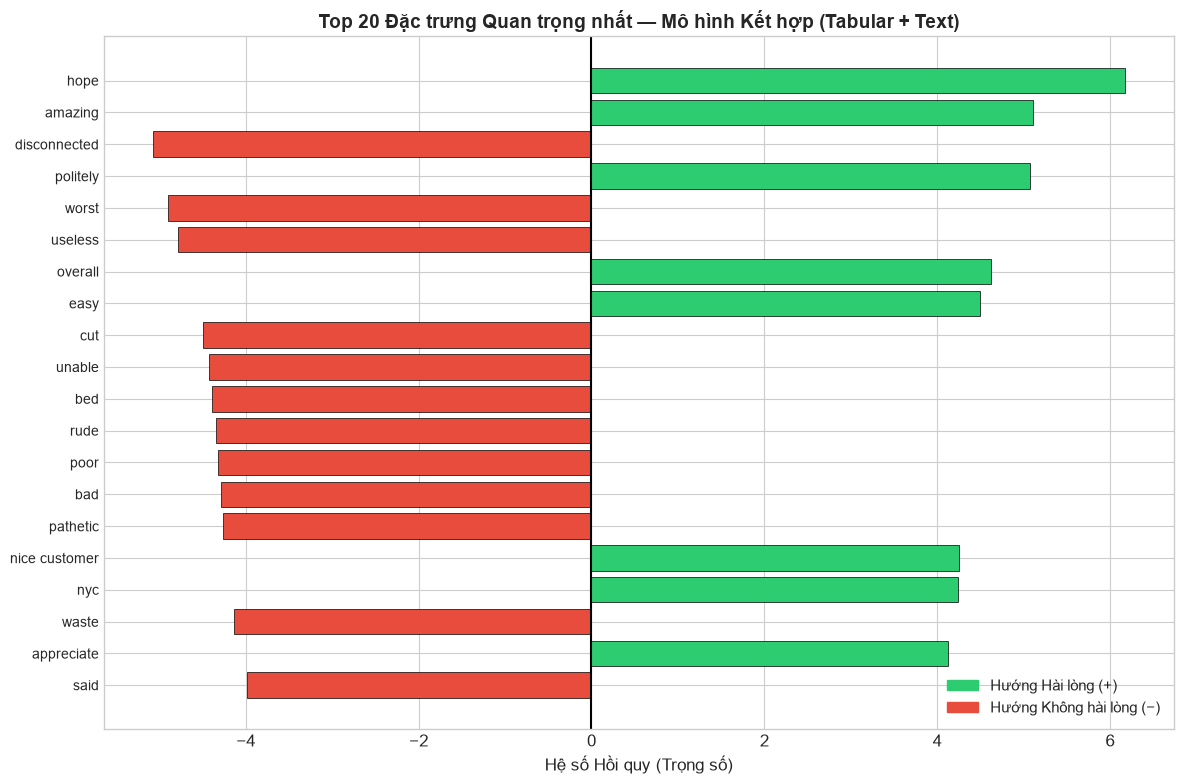

In [51]:
# 4.6.2 Biểu đồ Horizontal Barplot — Top 20 Đặc trưng Quan trọng nhất
top_combined = sorted(zip(all_feat_names, coefs), key=lambda x: abs(x[1]), reverse=True)[:20]

names = [x[0] for x in top_combined][::-1]
values = [x[1] for x in top_combined][::-1]
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(names)), values, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.axvline(0, color='black', lw=1.5, linestyle='-')

ax.set_title('Top 20 Đặc trưng Quan trọng nhất — Mô hình Kết hợp (Tabular + Text)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hệ số Hồi quy (Trọng số)', fontsize=12)

# Thêm chú thích màu
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#2ecc71', label='Hướng Hài lòng (+)')
red_patch = mpatches.Patch(color='#e74c3c', label='Hướng Không hài lòng (−)')
ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

#### Phân tích Biểu đồ Feature Importance:
- 🔍 **Quan sát (Observation)**: Biểu đồ thể hiện sự giao thoa giữa các biến vận hành (`response_time_minutes`, `Tenure Bucket`, `channel_name`) và các từ khóa cảm xúc ("good", "worst", "bad", "excellent"). Các từ mang sắc thái tiêu cực (thanh màu đỏ) có độ lớn hệ số âm rất cao.
- 💡 **Diễn giải (Interpretation)**: Ngôn ngữ nhận xét của khách hàng phản ánh trực tiếp trải nghiệm cảm xúc. Khi khách hàng để lại từ "worst" hoặc "terrible", xác suất mô hình gán nhãn "Không hài lòng (At-Risk)" sẽ tăng vọt, lấn át cả các biến số học.
- ⚙️ **Ý nghĩa ML (ML Implication)**: Khẳng định sức mạnh của giải pháp đa phương thức (Multimodal) — kết hợp dữ liệu bảng và NLP giúp mô hình không bỏ sót bất kỳ tín hiệu cảnh báo nào từ người dùng.

---
### 4.7 Đánh giá Mô hình Tốt nhất trên Tập Kiểm thử (Final Test Evaluation)

In [52]:
# 4.7.1 Lựa chọn mô hình có F1-Score cao nhất trên tập Validation
top_model_name = comparison_df.iloc[0]['Mô hình']

# Ánh xạ mô hình và tập kiểm thử tương ứng
models_mapping = {
    '1. LR (Tabular)': (best_lr, X_test_tab),
    '2. DT (Tabular)': (best_dt, X_test_tab),
    '3. RF (Tabular)': (best_rf, X_test_tab),
    '4. SVM (Tabular)': (best_svm, X_test_tab),
    '5. LR (Text-only)': (best_text_lr, X_test_text),
    '6. LR (Tabular+Text)': (best_combined, X_test_combined),
}

best_model, X_test_best = models_mapping[top_model_name]
print(f"Mô hình được chọn để triển khai (F1-Score cao nhất): '{top_model_name}'")

Mô hình được chọn để triển khai (F1-Score cao nhất): '5. LR (Text-only)'


In [53]:
# 4.7.2 Classification Report trên tập TEST
y_test_pred = best_model.predict(X_test_best)

print("=" * 60)
print(f"  CLASSIFICATION REPORT TRÊN TẬP TEST ({top_model_name})")
print("=" * 60)
print(classification_report(y_test, y_test_pred,
                           target_names=['Không hài lòng (0)', 'Hài lòng (1)']))

  CLASSIFICATION REPORT TRÊN TẬP TEST (5. LR (Text-only))
                    precision    recall  f1-score   support

Không hài lòng (0)       0.54      0.34      0.42      2025
      Hài lòng (1)       0.88      0.94      0.91      9961

          accuracy                           0.84     11986
         macro avg       0.71      0.64      0.66     11986
      weighted avg       0.82      0.84      0.83     11986



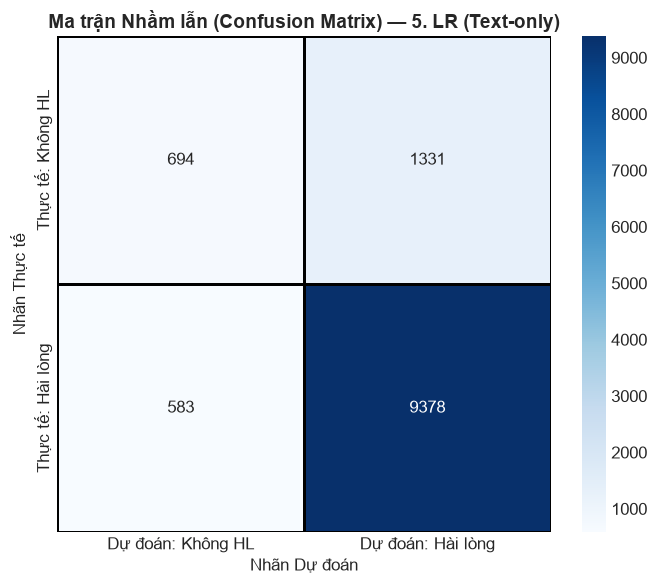

In [54]:
# 4.7.3 Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán: Không HL', 'Dự đoán: Hài lòng'],
            yticklabels=['Thực tế: Không HL', 'Thực tế: Hài lòng'],
            ax=ax, linewidths=1, linecolor='black')
ax.set_title(f'Ma trận Nhầm lẫn (Confusion Matrix) — {top_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Nhãn Thực tế', fontsize=12)
ax.set_xlabel('Nhãn Dự đoán', fontsize=12)
plt.tight_layout()
plt.show()

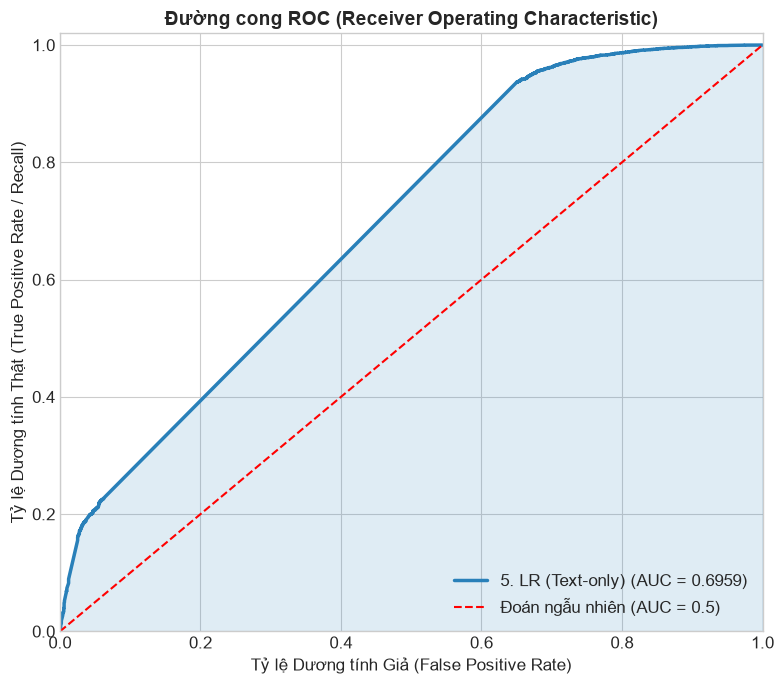

In [55]:
# 4.7.4 Đường cong ROC (ROC Curve)
if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test_best)[:, 1]
else:
    y_score = best_model.decision_function(X_test_best)

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'{top_model_name} (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Đoán ngẫu nhiên (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15, color='#2980b9')

ax.set_title('Đường cong ROC (Receiver Operating Characteristic)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontsize=12)
ax.set_ylabel('Tỷ lệ Dương tính Thật (True Positive Rate / Recall)', fontsize=12)
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## Phần 5: Lưu trữ và Triển khai (Persistence & Deployment)

### 5.1 Đóng gói và Lưu trữ Pipeline Đa phương thức

In [56]:
# 5.1.1 Đóng gói toàn bộ Preprocessors + Best Model + Metadata
os.makedirs('models', exist_ok=True)

# Triển khai mô hình kết hợp (Combined) để tận dụng cả Tabular + Text
deploy_model = best_combined

artifact = {
    'model': deploy_model,
    'preprocessor_tabular': preprocessor_tabular,
    'tfidf_vectorizer': tfidf_vectorizer,
    'tabular_features': tabular_features,
    'continuous_features': continuous_features,
    'encoded_features': encoded_features,
    'text_column': text_column,
    'channel_map': {'Inbound': 0, 'Outcall': 1, 'Email': 2},
    'tenure_map': {'On Job Training': 0, '0-30': 1, '31-60': 2, '61-90': 3, '>90': 4},
    'shift_map': {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3, 'Split': 4},
    'category_map': cat_map,
    'subcat_freq_map': subcat_freq.to_dict(),
    'model_name': top_model_name
}

# Lưu Joblib
joblib_path = 'models/csat_pipeline.joblib'
joblib.dump(artifact, joblib_path)
print(f"[1] Đã lưu Joblib: '{joblib_path}' ({os.path.getsize(joblib_path)/1024:.1f} KB)")

# Lưu Pickle (.sav)
sav_path = 'models/csat_model.sav'
with open(sav_path, 'wb') as f:
    pickle.dump(artifact, f)
print(f"[2] Đã lưu Pickle: '{sav_path}' ({os.path.getsize(sav_path)/1024:.1f} KB)")

[1] Đã lưu Joblib: 'models/csat_pipeline.joblib' (28.0 KB)
[2] Đã lưu Pickle: 'models/csat_model.sav' (27.3 KB)


In [57]:
# 5.1.2 Kiểm thử nạp lại Pipeline
loaded = joblib.load('models/csat_pipeline.joblib')
pipe_model = loaded['model']
pipe_preproc = loaded['preprocessor_tabular']
pipe_tfidf = loaded['tfidf_vectorizer']

# Test case 1: Không có nhận xét
test_tab = pd.DataFrame([{
    'channel_name': 0, 'category': 0, 'Tenure Bucket': 4, 'Agent Shift': 0,
    'response_time_minutes': 5.0, 'hour_reported': 10, 'day_of_week': 1, 'subcat_freq': 0.05
}])
test_text = ['']

tab_scaled = pipe_preproc.transform(test_tab)
text_vec = pipe_tfidf.transform(test_text)
combined = hstack([csr_matrix(tab_scaled), text_vec])
pred = pipe_model.predict(combined)[0]
prob = pipe_model.predict_proba(combined)[0]
print(f"Test 1 (Không có nhận xét): Dự đoán = {'Hài lòng' if pred == 1 else 'Không hài lòng'} | P(satisfied) = {prob[1]:.4f}")

# Test case 2: Nhận xét tích cực
test_text_2 = ['very fast and helpful excellent service']
text_vec_2 = pipe_tfidf.transform(test_text_2)
combined_2 = hstack([csr_matrix(tab_scaled), text_vec_2])
pred_2 = pipe_model.predict(combined_2)[0]
prob_2 = pipe_model.predict_proba(combined_2)[0]
print(f"Test 2 (Nhận xét tích cực):  Dự đoán = {'Hài lòng' if pred_2 == 1 else 'Không hài lòng'} | P(satisfied) = {prob_2[1]:.4f}")

# Test case 3: Nhận xét tiêu cực
test_text_3 = ['terrible service delayed for days worst experience']
text_vec_3 = pipe_tfidf.transform(test_text_3)
combined_3 = hstack([csr_matrix(tab_scaled), text_vec_3])
pred_3 = pipe_model.predict(combined_3)[0]
prob_3 = pipe_model.predict_proba(combined_3)[0]
print(f"Test 3 (Nhận xét tiêu cực):  Dự đoán = {'Hài lòng' if pred_3 == 1 else 'Không hài lòng'} | P(satisfied) = {prob_3[1]:.4f}")

Test 1 (Không có nhận xét): Dự đoán = Hài lòng | P(satisfied) = 0.5518
Test 2 (Nhận xét tích cực):  Dự đoán = Hài lòng | P(satisfied) = 0.9831
Test 3 (Nhận xét tiêu cực):  Dự đoán = Không hài lòng | P(satisfied) = 0.0185


### 5.2 Tạo Server REST API (`REST_API.py`) — Endpoint `/csat/v1/predict`

In [58]:
# 5.2.1 Tạo file REST_API.py (Flask — Cổng 5003)
flask_code = """import pickle
import os
import re
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify
from scipy.sparse import hstack, csr_matrix

app = Flask(__name__)

filename = os.path.join(os.path.dirname(__file__), 'models', 'csat_model.sav')
with open(filename, 'rb') as f:
    artifact = pickle.load(f)

model = artifact['model']
preprocessor_tabular = artifact['preprocessor_tabular']
tfidf_vectorizer = artifact['tfidf_vectorizer']
tabular_features = artifact['tabular_features']
channel_map = artifact['channel_map']
tenure_map = artifact['tenure_map']
shift_map = artifact['shift_map']
category_map = artifact['category_map']
subcat_freq_map = artifact['subcat_freq_map']
model_name = artifact.get('model_name', 'Combined Model')

@app.route('/csat/v1/predict', methods=['POST'])
def predict():
    features = request.json
    if not features:
        return jsonify({'error': 'No input data provided'}), 400

    channel = channel_map.get(features.get('channel', 'Inbound'), 0)
    category = category_map.get(features.get('category', 'Returns'), 0)
    tenure = tenure_map.get(features.get('tenure', '>90'), 4)
    shift = shift_map.get(features.get('shift', 'Morning'), 0)
    response_time = float(features.get('response_time', 10))
    hour = int(features.get('hour', 10))
    day = int(features.get('day_of_week', 1))
    subcat = features.get('subcategory', '')
    subcat_freq = subcat_freq_map.get(subcat, 0.01)
    remarks = features.get('remarks', '')

    remarks_clean = re.sub(r'[^a-z0-9\\s]', ' ', remarks.lower()).strip()

    row = pd.DataFrame([{
        'channel_name': channel, 'category': category,
        'Tenure Bucket': tenure, 'Agent Shift': shift,
        'response_time_minutes': response_time,
        'hour_reported': hour, 'day_of_week': day,
        'subcat_freq': subcat_freq
    }])

    tab_scaled = preprocessor_tabular.transform(row)
    text_vec = tfidf_vectorizer.transform([remarks_clean])
    combined = hstack([csr_matrix(tab_scaled), text_vec])

    pred = int(model.predict(combined)[0])
    prob = model.predict_proba(combined)[0].tolist()

    return jsonify({
        'prediction': pred,
        'label': 'Satisfied' if pred == 1 else 'At-Risk',
        'confidence': round(max(prob) * 100, 1),
        'probability_satisfied': round(prob[1] * 100, 1),
        'probability_at_risk': round(prob[0] * 100, 1),
        'model_used': model_name
    })

if __name__ == '__main__':
    print(f"[OK] Flask CSAT API dang chay tai http://127.0.0.1:5003")
    app.run(host='0.0.0.0', port=5003)
"""

with open('REST_API.py', 'w', encoding='utf-8') as f:
    f.write(flask_code)
print("Đã tạo thành công file 'REST_API.py'!")

Đã tạo thành công file 'REST_API.py'!


### 5.3 Kiểm thử REST API bằng lệnh `cURL`

**Trường hợp 1: Khách hàng không để lại nhận xét**
```bash
curl -H "Content-type: application/json" -X POST http://127.0.0.1:5003/csat/v1/predict -d "{\"channel\":\"Inbound\", \"category\":\"Returns\", \"tenure\":\">90\", \"shift\":\"Morning\", \"response_time\": 5, \"remarks\": \"\"}"
```

**Trường hợp 2: Khách hàng khen ngợi**
```bash
curl -H "Content-type: application/json" -X POST http://127.0.0.1:5003/csat/v1/predict -d "{\"channel\":\"Inbound\", \"category\":\"Returns\", \"response_time\": 3, \"remarks\": \"Very good service, fast and helpful\"}"
```

**Trường hợp 3: Khách hàng phàn nàn gay gắt**
```bash
curl -H "Content-type: application/json" -X POST http://127.0.0.1:5003/csat/v1/predict -d "{\"channel\":\"Email\", \"category\":\"Refund Related\", \"response_time\": 200, \"remarks\": \"Terrible delay worst experience pathetic service\"}"
```

### 5.4 Tạo Ứng dụng Client Python (`Predict_CSAT.py`)

In [59]:
# 5.4.1 Tạo file Client Predict_CSAT.py
client_code = """import json
import requests

def predict_csat(channel, category, tenure, shift, response_time, remarks=""):
    url = "http://127.0.0.1:5003/csat/v1/predict"
    data = {
        "channel": channel,
        "category": category,
        "tenure": tenure,
        "shift": shift,
        "response_time": float(response_time),
        "remarks": remarks
    }
    headers = {"Content-type": "application/json"}
    try:
        response = requests.post(url, data=json.dumps(data), headers=headers)
        return json.loads(response.text)
    except Exception as e:
        return {"error": str(e)}

if __name__ == "__main__":
    print("=" * 65)
    print("  DU DOAN MUC DO HAI LONG KHACH HANG (CSAT PREDICTION)")
    print("=" * 65)

    channel = input("Kenh lien he (Inbound/Outcall/Email)? ") or "Inbound"
    category = input("Danh muc su co (Returns/Order Related/Refund Related)? ") or "Returns"
    tenure = input("Kinh nghiem nhan vien (On Job Training/0-30/31-60/61-90/>90)? ") or ">90"
    shift = input("Ca truc (Morning/Afternoon/Evening/Night)? ") or "Morning"
    response_time = input("Thoi gian phan hoi (phut)? ") or "10"
    remarks = input("Nhan xet cua khach hang (de trong neu khong co)? ") or ""

    result = predict_csat(channel, category, tenure, shift, response_time, remarks)

    if "error" in result:
        print(f"\n[Loi]: {result['error']}")
    else:
        label = result['label']
        conf = result['confidence']
        icon = "[HAI LONG]" if label == "Satisfied" else "[CANH BAO - NGUY CO]"
        print(f"\n{icon} Ket qua: {label} (Do tin cay: {conf}%)")
        print(f"  P(Hai long):     {result['probability_satisfied']}%")
        print(f"  P(Khong hai long): {result['probability_at_risk']}%")
"""

with open('Predict_CSAT.py', 'w', encoding='utf-8') as f:
    f.write(client_code)
print("Đã tạo thành công file Client 'Predict_CSAT.py'!")

Đã tạo thành công file Client 'Predict_CSAT.py'!


In [60]:
# 5.4.2 Demo dự đoán trực tiếp trong Notebook (In-Memory Validation)
def local_predict(channel='Inbound', category_val=0, tenure=4, shift=0,
                  response_time=10, remarks=''):
    row = pd.DataFrame([{
        'channel_name': channel_map.get(channel, 0),
        'category': category_val,
        'Tenure Bucket': tenure,
        'Agent Shift': shift,
        'response_time_minutes': response_time,
        'hour_reported': 10,
        'day_of_week': 1,
        'subcat_freq': 0.05
    }])

    remarks_clean = re.sub(r'[^a-z0-9\s]', ' ', remarks.lower()).strip()

    tab_s = pipe_preproc.transform(row)
    text_s = pipe_tfidf.transform([remarks_clean])
    comb = hstack([csr_matrix(tab_s), text_s])

    pred = pipe_model.predict(comb)[0]
    prob = pipe_model.predict_proba(comb)[0]
    label = 'Hài lòng' if pred == 1 else 'NGUY CƠ'
    print(f"  Kênh: {channel} | Phản hồi: {response_time} phút | Nhận xét: '{remarks}'")
    print(f"  -> Kết quả: {label} | P(Hài lòng) = {prob[1]*100:.1f}%\n")

print("Demo 1: Xử lý nhanh, không nhận xét")
local_predict(response_time=3, remarks='')

print("Demo 2: Xử lý nhanh, khen ngợi")
local_predict(response_time=5, remarks='Very good fast service')

print("Demo 3: Chờ lâu qua Email, phàn nàn gay gắt")
local_predict(channel='Email', response_time=180, remarks='worst delay terrible bad experience')

Demo 1: Xử lý nhanh, không nhận xét
  Kênh: Inbound | Phản hồi: 3 phút | Nhận xét: ''
  -> Kết quả: Hài lòng | P(Hài lòng) = 55.2%

Demo 2: Xử lý nhanh, khen ngợi
  Kênh: Inbound | Phản hồi: 5 phút | Nhận xét: 'Very good fast service'
  -> Kết quả: Hài lòng | P(Hài lòng) = 79.1%

Demo 3: Chờ lâu qua Email, phàn nàn gay gắt
  Kênh: Email | Phản hồi: 180 phút | Nhận xét: 'worst delay terrible bad experience'
  -> Kết quả: NGUY CƠ | P(Hài lòng) = 0.2%



---
## 6. HƯỚNG DẪN VẬN HÀNH TOÀN DIỆN HỆ THỐNG (OPERATIONAL GUIDE)

> **Mục tiêu**: Hướng dẫn triển khai, kiểm thử và vận hành hệ thống dự đoán mức độ hài lòng khách hàng thương mại điện tử (CSAT) theo chuẩn cấu trúc **Appendix A** của học phần.

### 6.1. Cấu trúc Thành phần Bàn giao
* `data/`: Tệp dữ liệu vận hành & phản hồi khách hàng `Customer_support_data.csv`.
* `model/`: Mô hình và tiền xử lý đa phương thức (`preprocessor.joblib`, `model.joblib`, `csat_pipeline.joblib`).
* `api/`: Dịch vụ REST API dự đoán CSAT độc lập theo chuẩn Appendix C (FastAPI, Port 8003).
* `web/`: Giao diện Web Desktop phân tích sắc thái phản hồi (Port 8103).
* `mobile/`: Ứng dụng di động gồm Mobile Touch Client (Port 8203) và mã nguồn React Native (Expo).

---

### 6.2. Hướng dẫn Khởi chạy Dịch vụ

#### Cách 1: Khởi chạy nhanh Toàn diện (All-in-One Server)
Mở terminal tại thư mục `customer_behavior/`:
```bash
python -m uvicorn app:app --port 8003
```
* **Giao diện Web Desktop**: Mở trình duyệt tại `http://localhost:8003/`
* **Giao diện Mobile Touch**: Mở trình duyệt tại `http://localhost:8003/mobile`
* **API Documentation (Swagger UI)**: `http://localhost:8003/docs`

#### Cách 2: Khởi chạy Tách biệt Từng Thành phần
1. **Khởi chạy Microservice REST API (Port 8003)**:
   ```bash
   cd customer_behavior/api
   python -m uvicorn app:app --port 8003
   ```
   *Kiểm thử tự động bằng Client Python*:
   ```bash
   python test_api.py
   ```

2. **Khởi chạy Giao diện Web Desktop (Port 8103)**:
   ```bash
   cd customer_behavior/web
   python -m uvicorn app:app --port 8103
   ```
   Truy cập: `http://localhost:8103`

3. **Khởi chạy Giao diện Di động (Mobile)**:
   * **Bản Mobile Touch Web (Trực tiếp)**:
     ```bash
     cd customer_behavior/mobile
     python -m uvicorn app:app --port 8203
     ```
     Truy cập: `http://localhost:8203`
   * **Bản React Native (Expo Go trên điện thoại)**:
     ```bash
     cd customer_behavior/mobile
     npm install
     npx expo start
     ```
     Quét mã QR bằng ứng dụng Expo Go trên thiết bị Android/iOS.

---

### 6.3. Đặc tả Giao thức REST API (Appendix C)
* **Endpoint**: `POST http://localhost:8003/predict`
* **Headers**: `Content-Type: application/json`
* **Dữ liệu gửi lên (Request Body mẫu)**:
```json
{
  "channel": "Inbound",
  "category": "Returns",
  "tenure": ">90",
  "shift": "Morning",
  "response_time": 8.0,
  "remarks": "The agent was super polite and helped resolve my return immediately!"
}
```
* **Dữ liệu phản hồi (Response Body mẫu)**:
```json
{
  "prediction": 1,
  "label": "Satisfied",
  "confidence": 82.4,
  "probability_satisfied": 82.4,
  "probability_at_risk": 17.6,
  "model_used": "LogisticRegression"
}
```
